In [56]:
import os
import json
import pandas as pd
import numpy as np
import glob
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

In [ ]:
def process_rehab_json(file_paths):
    dataset_rows = []
    
    for file_path in file_paths:
        with open(file_path, 'r', encoding='utf-8') as f:
            docs = json.load(f) 
            
            if isinstance(docs, dict):
                docs = [docs]
                
            for doc in docs:
                planning_date_str = doc.get('planningDate', {}).get('$date')
                if not planning_date_str:
                    continue
                planning_date = pd.to_datetime(planning_date_str).tz_localize(None)
                
                board = doc.get('board', [])
                unassigned = doc.get('unassignedPatients', [])
                
                if not board:
                    continue
                
                # --- 1. Calcolo del Contesto Globale Giornaliero ---
                total_operators = len(board)
                
                # Raccogliamo i pazienti unici della giornata usando l'ID per evitare duplicati
                daily_patients = {}
                for op in board:
                    for pat in op.get('patients', []):
                        if 'id' in pat:
                            daily_patients[pat['id']] = pat
                for pat in unassigned:
                    if 'id' in pat:
                        daily_patients[pat['id']] = pat
                        
                total_patients_needing_care = len(daily_patients)
                density_ratio = (total_patients_needing_care / total_operators) if total_operators > 0 else np.nan
                
                # Contiamo tipi di pazienti e necessità di ausili (Lifter)
                patient_type_counts = {}
                total_lifters = 0
                
                for pat in daily_patients.values():
                    p_type = pat.get('type')
                    if p_type:
                        patient_type_counts[p_type] = patient_type_counts.get(p_type, 0) + 1
                    
                    # Contiamo i pazienti che richiedono sollevatore
                    if pat.get('aidNeeds') == 'lifter':
                        total_lifters += 1
                        
                # Percentuale di pazienti gravi nel giorno
                daily_lifter_ratio = (total_lifters / total_patients_needing_care) if total_patients_needing_care > 0 else 0
                
                # Feature Temporali
                day_of_week = planning_date.day_name() # Es: 'Monday', 'Tuesday'
                is_weekend = 1 if planning_date.weekday() >= 5 else 0 # 1 se Sabato/Domenica
                
                # --- 2. Estrazione delle feature per SINGOLO OPERATORE ---
                for op in board:
                    qualifications = op.get('qualifications', [])
                    
                    op_matching_patients = sum(patient_type_counts.get(q, 0) for q in qualifications)
                    target_assignments = op.get('assignments', len(op.get('patients', [])))
                    
                    row = {
                        'planning_date': planning_date,
                        'day_of_week': day_of_week,
                        'is_weekend': is_weekend,
                        
                        # Feature Operatore (Native)
                        'op_jobKind': op.get('jobKind'),
                        'op_burdenScore': op.get('burdenScore'),
                        'op_qualifications_count': len(qualifications),
                        
                        # Flag specifici delle qualifiche (One-Hot manuale)
                        'op_has_N': 1 if 'N' in qualifications else 0,
                        'op_has_O': 1 if 'O' in qualifications else 0,
                        'op_has_CN': 1 if 'CN' in qualifications else 0,
                        
                        # Feature di Contesto (Derivate)
                        'total_patients_needing_care': total_patients_needing_care,
                        'density_ratio': density_ratio,
                        'op_matching_patients': op_matching_patients,
                        'daily_lifter_ratio': daily_lifter_ratio,
                        
                        # TARGET (Y)
                        'target_assignments': float(target_assignments)
                    }
                    
                    dataset_rows.append(row)
                    
    return pd.DataFrame(dataset_rows)

json_files = glob.glob("data/*.json")
df = process_rehab_json(json_files)

print(f"Estratte {len(df)} giornate/operatore con {len(df.columns)} feature.")
display(df.head())

Estratte 2345 giornate/operatore con 14 feature.


,planning_date,day_of_week,is_weekend,op_jobKind,op_burdenScore,op_qualifications_count,op_has_N,op_has_O,op_has_CN,total_patients_needing_care,density_ratio,op_matching_patients,daily_lifter_ratio,target_assignments
0,2022-12-01,Thursday,0,full-time,4,5,1,1,0,111,5.045455,111,0.045045,6.0
1,2022-12-01,Thursday,0,full-time,2,6,1,1,1,111,5.045455,111,0.045045,5.0
2,2022-12-01,Thursday,0,full-time,2,6,1,1,0,111,5.045455,111,0.045045,4.0
3,2022-12-01,Thursday,0,full-time,4,6,1,1,1,111,5.045455,111,0.045045,5.0
4,2022-12-01,Thursday,0,full-time,2,6,1,1,1,111,5.045455,111,0.045045,5.0


In [ ]:
def generate_statistical_report(df):
    report_data = []
    
    for col in df.columns:
        dtype = str(df[col].dtype)
        n_unique = df[col].nunique()
        n_missing = df[col].isnull().sum()
        pct_missing = (n_missing / len(df)) * 100
        
        # Analisi della distribuzione
        if pd.api.types.is_numeric_dtype(df[col]) and n_unique > 2:
            # Per le numeriche
            dist_info = f"Min: {df[col].min():.1f} | Media: {df[col].mean():.1f} | Max: {df[col].max():.1f}"
        else:
            # Per categoriche, booleane o numeriche con pochissimi valori
            top_vals = df[col].value_counts().head(3).to_dict()
            dist_info = "Top val: " + ", ".join([f"{k} ({v})" for k, v in top_vals.items()])
            
        report_data.append({
            'Feature': col,
            'Tipo': dtype,
            'Valori Distinti': n_unique,
            'Valori Mancanti': f"{n_missing} ({pct_missing:.1f}%)",
            'Distribuzione': dist_info
        })
        
    report_df = pd.DataFrame(report_data)
    return report_df

stats_report = generate_statistical_report(df)
display(stats_report)


,Feature,Tipo,Valori Distinti,Valori Mancanti,Distribuzione
0,planning_date,datetime64[us],63,0 (0.0%),"Top val: 2023-01-19 00:00:00 (41), 2023-01-26 ..."
1,day_of_week,str,5,0 (0.0%),"Top val: Tuesday (498), Wednesday (486), Thurs..."
2,is_weekend,int64,1,0 (0.0%),Top val: 0 (2345)
3,op_jobKind,str,3,0 (0.0%),"Top val: full-time (1732), part-time on mornin..."
4,op_burdenScore,int64,8,0 (0.0%),Min: 2.0 | Media: 3.9 | Max: 11.0
5,op_qualifications_count,int64,6,0 (0.0%),Min: 2.0 | Media: 4.7 | Max: 7.0
6,op_has_N,int64,1,0 (0.0%),Top val: 1 (2345)
7,op_has_O,int64,1,0 (0.0%),Top val: 1 (2345)
8,op_has_CN,int64,2,0 (0.0%),"Top val: 0 (1695), 1 (650)"
9,total_patients_needing_care,int64,35,0 (0.0%),Min: 43.0 | Media: 85.8 | Max: 115.0


In [59]:
def initial_hygiene_cleaning(df):
    print(f"Dimensioni originali: {df.shape}")

    # Identificazione e rimozione delle feature costanti
    constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
    
    if constant_cols:
        df_clean = df.drop(columns=constant_cols)
        print(f"Rimosse feature costanti: {constant_cols}")
    else:
        print("Nessuna feature costante trovata.")
        
    print(f"Dimensioni finali dataset base: {df_clean.shape}")
    return df_clean

# Esecuzione
df_clean = initial_hygiene_cleaning(df)

Dimensioni originali: (2345, 14)
Rimosse feature costanti: ['is_weekend', 'op_has_N', 'op_has_O']
Dimensioni finali dataset base: (2345, 11)


In [60]:
def chronological_train_test_split(df, train_ratio=0.8):
    # Ordinamento del dataset per data di pianificazione
    df_sorted = df.sort_values('planning_date').reset_index(drop=True)
    
    # Calcolo dell'indice esatto in cui tagliare
    split_idx = int(len(df_sorted) * train_ratio)
    
    # Divisione in Train e Test
    df_train = df_sorted.iloc[:split_idx].copy()
    df_test = df_sorted.iloc[split_idx:].copy()
    
    print(f"Dati totali: {len(df_sorted)}")
    print(f"Train set: {len(df_train)} record (dal {df_train['planning_date'].min().date()} al {df_train['planning_date'].max().date()})")
    print(f"Test set:  {len(df_test)} record (dal {df_test['planning_date'].min().date()} al {df_test['planning_date'].max().date()})")
    
    # Rimozione della colonna data, non più necessaria
    df_train = df_train.drop(columns=['planning_date'])
    df_test = df_test.drop(columns=['planning_date'])
    
    return df_train, df_test

df_train, df_test = chronological_train_test_split(df_clean, train_ratio=0.8)

X_train = df_train.drop(columns=['target_assignments'])
y_train = df_train['target_assignments']

X_test = df_test.drop(columns=['target_assignments'])
y_test = df_test['target_assignments']

Dati totali: 2345
Train set: 1876 record (dal 2022-11-02 al 2023-01-16)
Test set:  469 record (dal 2023-01-16 al 2023-01-31)


In [61]:
def apply_correlation_filter(df_train, df_test, threshold=0.90, protected_features=['density_ratio']):
    # Calcolo correlazione
    num_df = df_train.select_dtypes(include=[np.number])
    corr_matrix = num_df.corr().abs()
    
    # Identificazione feature da rimuovere, considerando le eccezioni
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    to_drop = []
    for column in upper.columns:
        # Se la colonna è fortemente correlata con qualcosa...
        if any(upper[column] > threshold):
            # ...e non è nella lista delle protette, la scartiamo.
            if column not in protected_features:
                to_drop.append(column)
            else:
                # Se è protetta, cerchiamo con cosa è correlata per scartare l'altra variabile
                correlated_with_protected = upper.index[upper[column] > threshold].tolist()
                to_drop.extend([c for c in correlated_with_protected if c not in protected_features])

    # Rimuozione eventuali duplicati dalla lista to_drop
    to_drop = list(set(to_drop))

    if to_drop:
        print(f"Feature rimosse per correlazione > {threshold}: {to_drop}")
        df_train_clean = df_train.drop(columns=to_drop)
        df_test_clean = df_test.drop(columns=to_drop)
    else:
        print(f"Nessuna feature supera la soglia di correlazione ({threshold}).")
        df_train_clean, df_test_clean = df_train.copy(), df_test.copy()
        
    return df_train_clean, df_test_clean

df_train_clean, df_test_clean = apply_correlation_filter(df_train, df_test, threshold=0.90)

Feature rimosse per correlazione > 0.9: ['total_patients_needing_care', 'op_matching_patients']


In [62]:
def safe_one_hot_encoding(df_train, df_test):
    cat_cols = df_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    
    # Esecuzione dell'encoding con get_dummies
    df_train_encoded = pd.get_dummies(df_train, columns=cat_cols, drop_first=True)
    df_test_encoded = pd.get_dummies(df_test, columns=cat_cols, drop_first=True)
    
    # Allineamento del test set al train set. 
    # - Se nel test manca una colonna del train, viene creata con tutti 0.
    # - Se nel test c'è una colonna nuova non vista nel train, viene ignorata/rimossa.
    df_train_encoded, df_test_encoded = df_train_encoded.align(df_test_encoded, join='left', axis=1, fill_value=0)
    
    # Conversione booleani in int
    bool_cols = df_train_encoded.select_dtypes(include='bool').columns
    df_train_encoded[bool_cols] = df_train_encoded[bool_cols].astype(int)
    df_test_encoded[bool_cols] = df_test_encoded[bool_cols].astype(int)
    
    # Normalizzazione nomi colonne
    df_train_encoded.columns = df_train_encoded.columns.astype(str)
    df_test_encoded.columns = df_test_encoded.columns.astype(str)
    
    print(f"Dimensioni finali Train: {df_train_encoded.shape}")
    print(f"Dimensioni finali Test: {df_test_encoded.shape}")
    
    return df_train_encoded, df_test_encoded

df_train_final, df_test_final = safe_one_hot_encoding(df_train_clean, df_test_clean)

df_train_final.to_csv("data/train_dataset.csv", index=False)
df_test_final.to_csv("data/test_dataset.csv", index=False)

Dimensioni finali Train: (1876, 12)
Dimensioni finali Test: (469, 12)


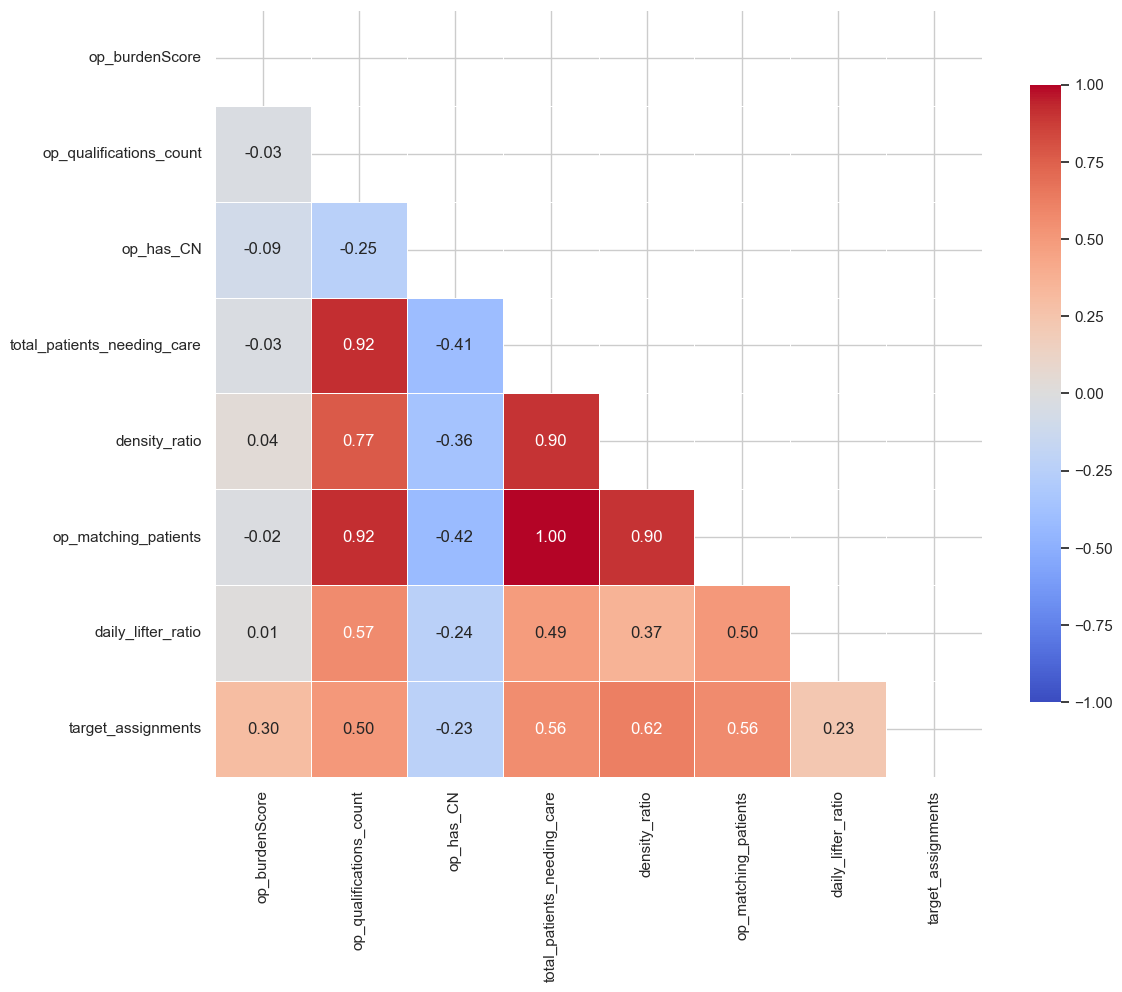

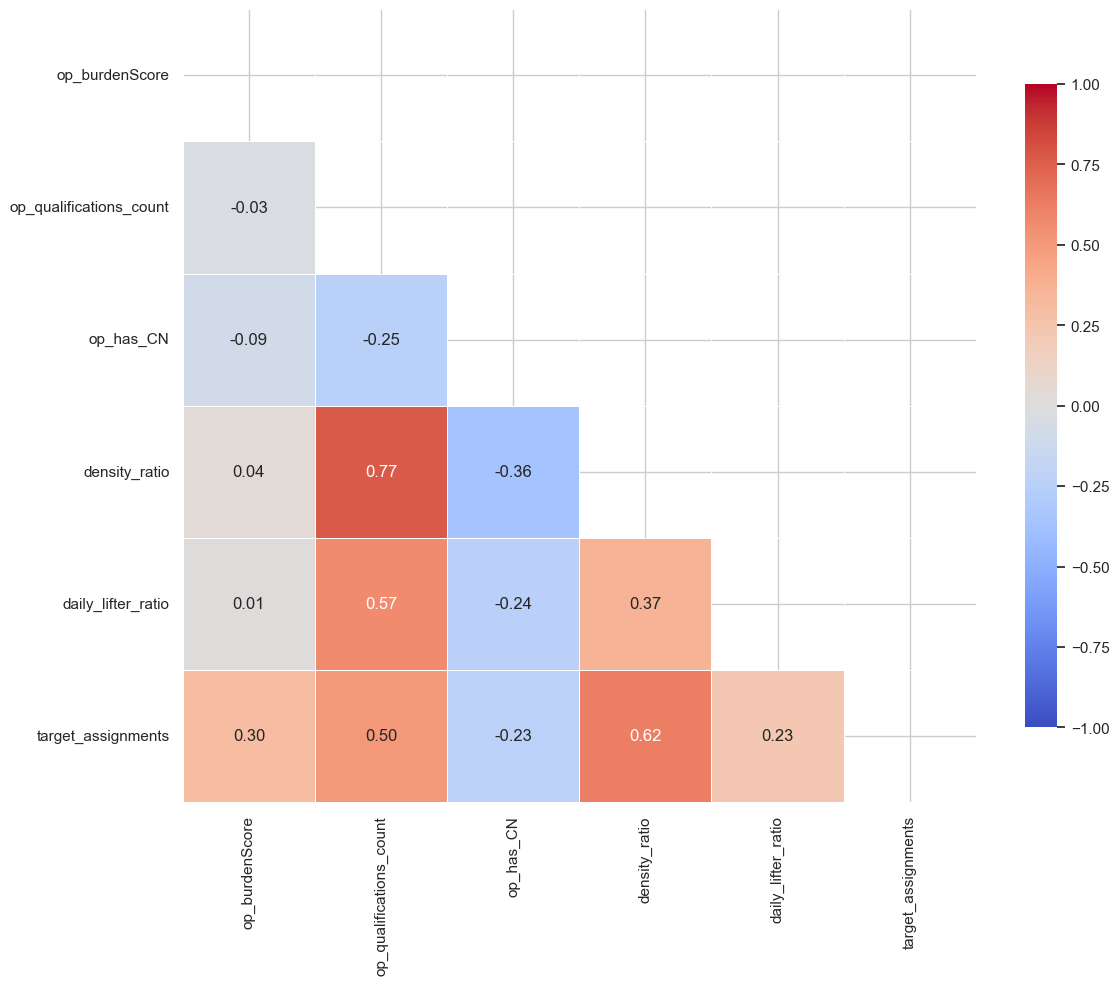

In [63]:
def plot_target_correlations(df, postfix, save_dir="images"):
    # 1. Variabili Numeriche: Matrice di Pearson
    num_df = df.select_dtypes(include=[np.number])
    
    # Calcoliamo la matrice di correlazione di Pearson
    corr_matrix = num_df.corr()
    
    # Impostiamo la dimensione della figura
    plt.figure(figsize=(12, 10))
    
    # Maschera per nascondere la metà superiore
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Disegniamo la heatmap
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
    
    plt.tight_layout()

    plt.savefig(f"{save_dir}/corr_pearson_target_{postfix}.png")
    plt.show()

plot_target_correlations(df_train, postfix="pre")
plot_target_correlations(df_train_clean, postfix="post")

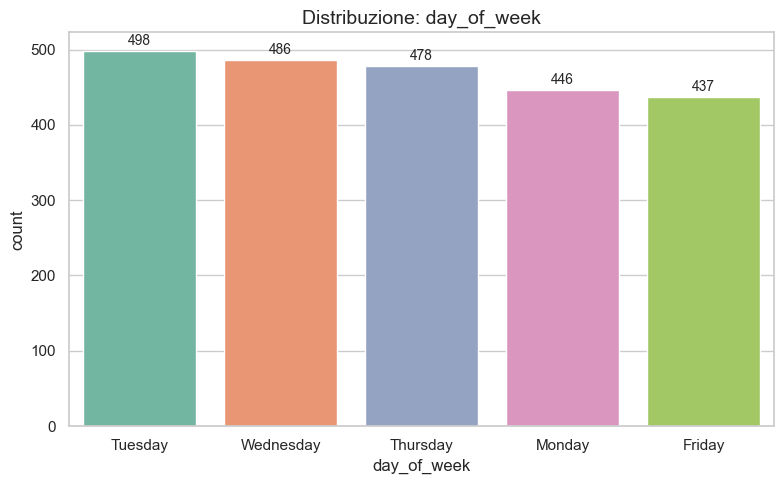

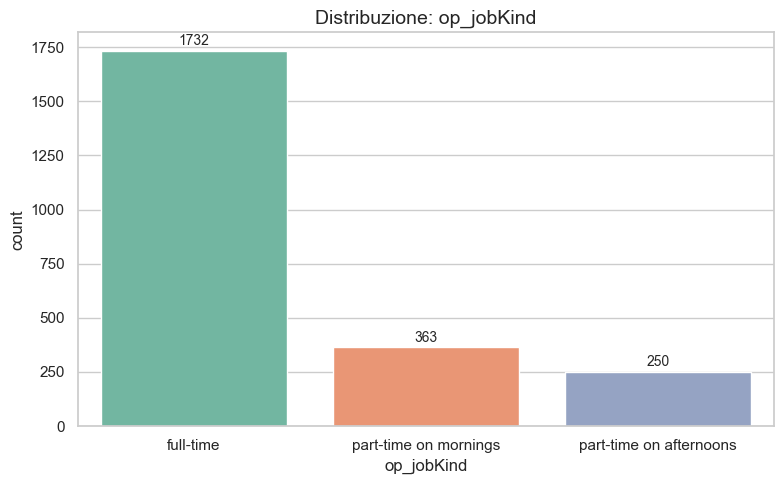

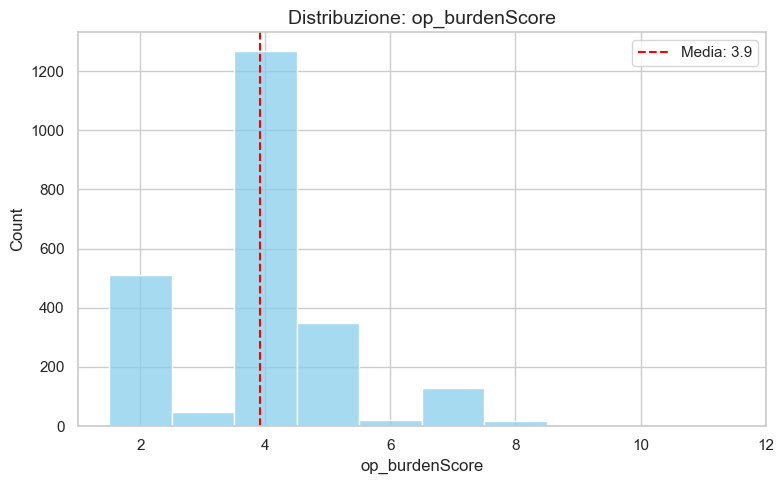

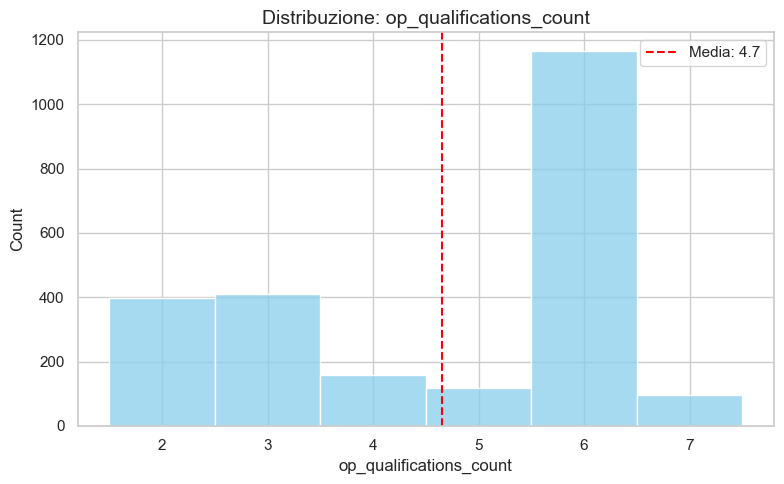

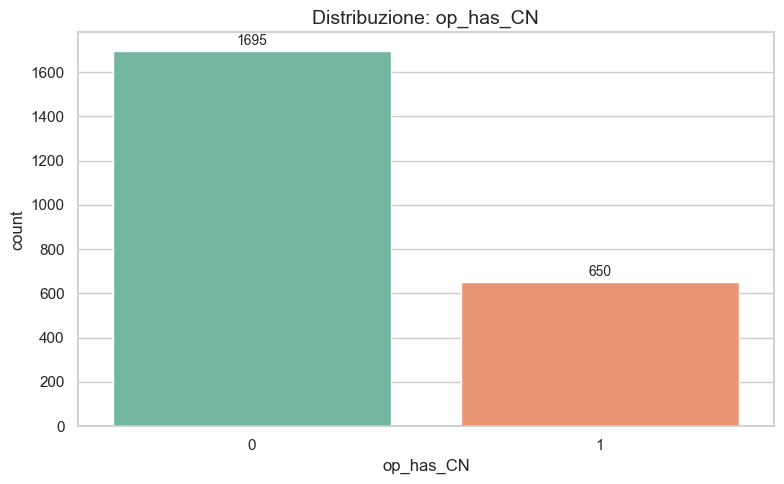

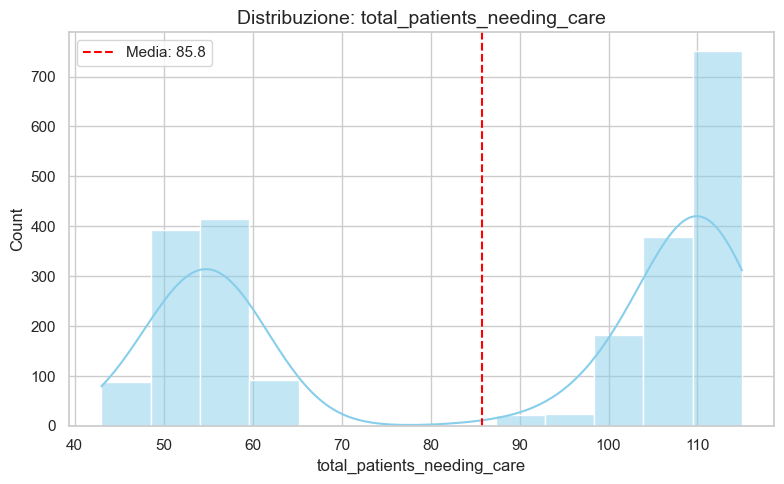

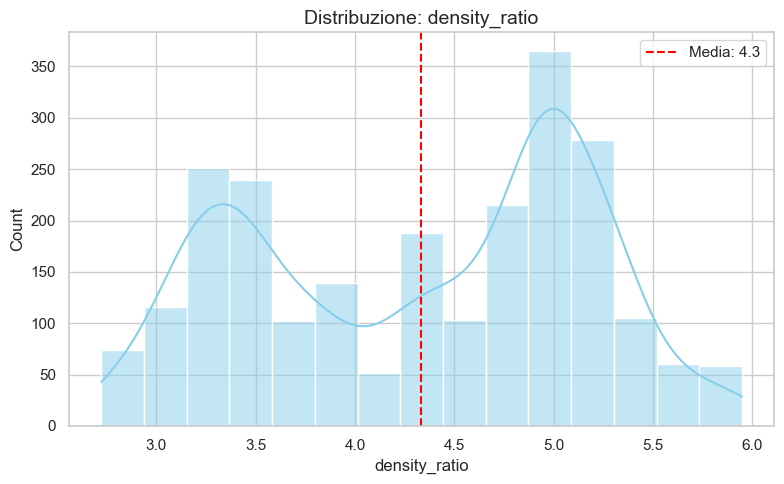

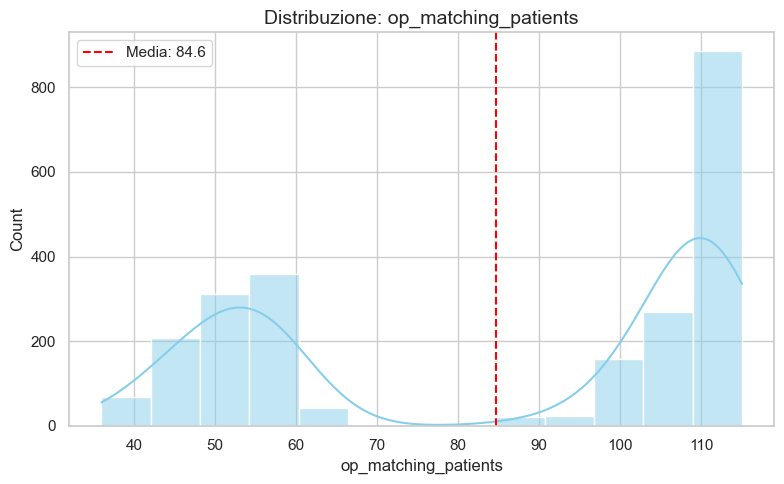

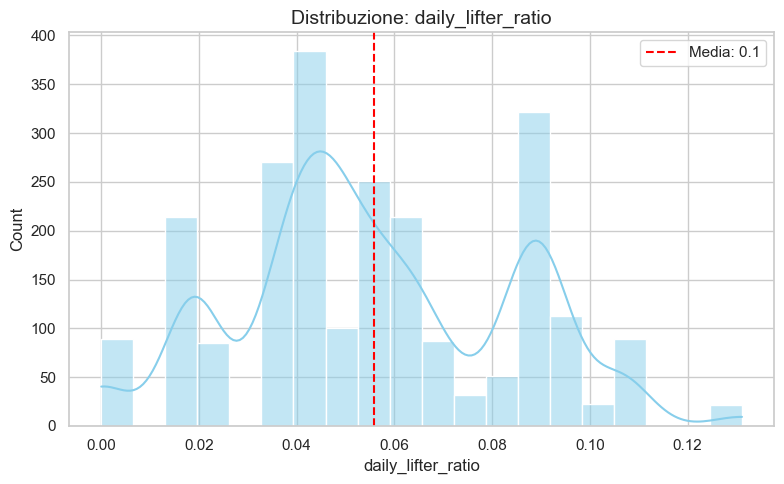

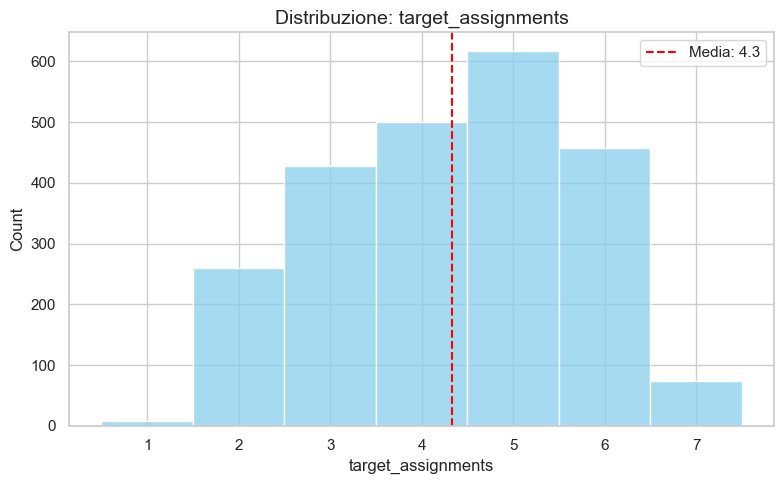

In [64]:
def plot_operator_distributions(df, feature_to_plot=None, save_dir="images"):
    os.makedirs(save_dir, exist_ok=True)
    sns.set_theme(style="whitegrid")

    if not feature_to_plot:
        features_to_plot = [col for col in df.columns if col != 'planning_date']
    
    for col in features_to_plot:
        plt.figure(figsize=(8, 5))
        
        if col in ['op_jobKind', 'day_of_week', 'is_weekend', 'op_has_CN']:
            # Variabile categorica
            ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
            plt.title(f"Distribuzione: {col}", fontsize=14)
            for p in ax.patches:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                            ha='center', va='bottom', fontsize=10, xytext=(0, 2), textcoords='offset points')
        else:
            # Variabili numeriche (discrete o continue)
            is_discrete = df[col].nunique() < 20
            sns.histplot(df[col].dropna(), kde=not is_discrete, discrete=is_discrete, color="skyblue")
            plt.axvline(df[col].mean(), color='red', linestyle='--', label=f'Media: {df[col].mean():.1f}')
            plt.title(f"Distribuzione: {col}", fontsize=14)
            plt.legend()
            
        plt.tight_layout()
        plt.savefig(f"{save_dir}/dist_{col}.png")
        plt.show()

plot_operator_distributions(df_clean)